# Train CNN with with Colab (GPU)

## Mounting to google colab, loading from google drive, paths...

In [2]:
from pathlib import Path
import sys
import os
import numpy as np


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive") # mount the drive
    DATA_PATH = Path("/content/drive/MyDrive") # the root of the drive
    DATA_ROOT = DATA_PATH / "cbc_pe_data" # the root of the data
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))
    DATA_ROOT = PROJECT_ROOT / "data"


DATA_RAW = DATA_ROOT / "raw" # the root of the raw data
DATA_PROCESSED = DATA_ROOT / "processed" # the root of the processed data
MODELS_DIR = DATA_ROOT / "models" # the root of the models
RESULTS_DIR = DATA_ROOT / "results" # the root of the results
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" # the root of the checkpoints

for path in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_RAW:", DATA_RAW)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CHECKPOINTS_DIR:", CHECKPOINTS_DIR)



#Clone the repository if it doesn't exist
if IN_COLAB:
    REPO_ROOT = Path("/content/Gravitational-Waves-Lab")
    PROJECT_ROOT = REPO_ROOT / "cbc_pe"

    if not REPO_ROOT.exists():
        !git clone https://github.com/victorsh13/Gravitational-Waves-Lab.git /content/Gravitational-Waves-Lab

    print("REPO_ROOT exists:", REPO_ROOT.exists())
    print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

    #Pull the latest version of the repository
    %cd /content/Gravitational-Waves-Lab
    !git pull
    !git status

    #Go to the project root
    %cd /content/Gravitational-Waves-Lab/cbc_pe
else:
    %cd /home/victor/gw/cbc_pe
    


# Add the project root to the python path
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("sys.path[:3]:", sys.path[:3])

DATA_ROOT: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data
DATA_RAW: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/raw
MODELS_DIR: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/models
RESULTS_DIR: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/results
CHECKPOINTS_DIR: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/models/checkpoints
[Errno 2] No such file or directory: '/home/victor/gw/cbc_pe'
/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
cwd: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe
sys.path[:3]: ['/home/victor/gw/Gravitational-Waves-Lab/cbc_pe', '/home/victor/miniconda3/envs/gw-env/lib/python311.zip', '/home/victor/miniconda3/envs/gw-env/lib/python3.11']


## Load the data

In [3]:
from pathlib import Path
import numpy as np

from src.io import load_dataset_npz

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n4500"

dataset_path = DATA_PROCESSED / f"{dataset_id}.npz"
split_path = DATA_PROCESSED / f"{dataset_id}_splits.npz"

assert dataset_path.exists(), dataset_path
assert split_path.exists(), split_path

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
metadata = batch.metadata

assert X.shape[0] == 4500
assert y.shape == (4500, 3)
assert isinstance(metadata, list)
assert len(metadata) == 4500

# SNR final de red, uno por muestra
network_snrs = np.array([
    m["snr"]["final_network_snr"]
    for m in metadata
], dtype=np.float32)

# SNR final por detector, uno por muestra y detector
detector_names = metadata[0]["detectors"]

detector_snrs = {
    det: np.array([
        m["snr"]["final_detector_snrs"][det]
        for m in metadata
    ], dtype=np.float32)
    for det in detector_names
}

print("X:", X.shape)
print("y:", y.shape)
print("network_snrs:", network_snrs.shape)
print("detectors:", detector_names)

print("Network SNR min/max:", network_snrs.min(), network_snrs.max())
for det in detector_names:
    print(det, detector_snrs[det].min(), detector_snrs[det].max())

splits = np.load(split_path)

train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
cal_idx = splits["cal_idx"]
test_idx = splits["test_idx"]

assert len(train_idx) == 3000
assert len(val_idx) == 500
assert len(cal_idx) == 500
assert len(test_idx) == 500

all_idx = np.concatenate([train_idx, val_idx, cal_idx, test_idx])
assert len(np.unique(all_idx)) == 4500
assert set(all_idx.tolist()) == set(range(4500))

X_train, y_train_phys = X[train_idx], y[train_idx]
X_val, y_val_phys = X[val_idx], y[val_idx]
X_cal, y_cal_phys = X[cal_idx], y[cal_idx]
X_test, y_test_phys = X[test_idx], y[test_idx]

snr_train = network_snrs[train_idx]
snr_val = network_snrs[val_idx]
snr_cal = network_snrs[cal_idx]
snr_test = network_snrs[test_idx]

X: (4500, 3, 16384)
y: (4500, 3)
network_snrs: (4500,)
detectors: ['H1', 'L1', 'V1']
Network SNR min/max: 10.001353 24.989826
H1 0.38514626 23.930038
L1 0.15105125 22.801056
V1 0.17619781 24.42133


## Load the splits (train, val) and (cal, test)

Split the data into:
- ``train``       : training the model
- ``val``         : early stopping / chosing the best model
- ``calibration`` : calibration of the conformal intervals
- ``test``        : final evaluation, independent of the model/training/calibration

Some reasonable splits: -

In [4]:
splits = np.load(split_path)

train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
cal_idx = splits["cal_idx"]
test_idx = splits["test_idx"]

assert len(train_idx) == 3000
assert len(val_idx) == 500
assert len(cal_idx) == 500
assert len(test_idx) == 500

all_idx = np.concatenate([train_idx, val_idx, cal_idx, test_idx])

assert len(np.unique(all_idx)) == 4500
assert set(all_idx.tolist()) == set(range(4500))

X_train, y_train_phys = X[train_idx], y[train_idx]
X_val, y_val_phys = X[val_idx], y[val_idx]
X_cal, y_cal_phys = X[cal_idx], y[cal_idx]
X_test, y_test_phys = X[test_idx], y[test_idx]

snr_train = network_snrs[train_idx]
snr_val = network_snrs[val_idx]
snr_cal = network_snrs[cal_idx]
snr_test = network_snrs[test_idx]

print("X_train:", X_train.shape, "y_train_phys:", y_train_phys.shape)
print("X_val:", X_val.shape, "y_val_phys:", y_val_phys.shape)
print("X_cal:", X_cal.shape, "y_cal_phys:", y_cal_phys.shape)
print("X_test:", X_test.shape, "y_test_phys:", y_test_phys.shape)

print("SNR train:", snr_train.min(), snr_train.max())
print("SNR val:", snr_val.min(), snr_val.max())
print("SNR cal:", snr_cal.min(), snr_cal.max())
print("SNR test:", snr_test.min(), snr_test.max())

X_train: (3000, 3, 16384) y_train_phys: (3000, 3)
X_val: (500, 3, 16384) y_val_phys: (500, 3)
X_cal: (500, 3, 16384) y_cal_phys: (500, 3)
X_test: (500, 3, 16384) y_test_phys: (500, 3)
SNR train: 10.001353 24.989826
SNR val: 10.018398 24.973204
SNR cal: 10.014041 24.970226
SNR test: 10.001784 24.944693


## Label Standardization

Standarize the labels using the mean and standard deviation of the training set and save it in DATA_PROCESSED.
This will be needed to revert the normalization and interpret the predictions as physical quantities.

In [5]:
label_names = ["chirp_mass", "total_mass", "chi_eff"]

y_mean = y_train_phys.mean(axis=0)
y_std = y_train_phys.std(axis=0)

eps = 1e-8
y_std_safe = y_std + eps

y_train_std = (y_train_phys - y_mean) / y_std_safe
y_val_std = (y_val_phys - y_mean) / y_std_safe
y_cal_std = (y_cal_phys - y_mean) / y_std_safe
y_test_std = (y_test_phys - y_mean) / y_std_safe

print("label_names:", label_names)
print("y_mean:", y_mean)
print("y_std:", y_std)

print("train std mean:", y_train_std.mean(axis=0))
print("train std std:", y_train_std.std(axis=0))
print("val std mean:", y_val_std.mean(axis=0))
print("val std std:", y_val_std.std(axis=0))

label_names: ['chirp_mass', 'total_mass', 'chi_eff']
y_mean: [3.746003e+01 9.524749e+01 1.227917e-02]
y_std: [16.318987   34.057907    0.43827724]
train std mean: [-1.3551314e-06 -1.7046929e-08  1.3152758e-08]
train std std: [1.0000005 1.        0.9999998]
val std mean: [ 0.01320857  0.00688598 -0.07395179]
val std std: [1.0057445  1.0062084  0.98145705]


## Data standardization

In [5]:
X_mean = X_train.mean(axis=(0, 2), keepdims=True)
X_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-30

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_cal_norm = (X_cal - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

print("X_train_norm mean/std global:", X_train_norm.mean(), X_train_norm.std())

for c, det in enumerate(["H1", "L1", "V1"]):
    print(det)
    print("  mean:", X_train_norm[:, c, :].mean())
    print("  std :", X_train_norm[:, c, :].std())
    print("  min :", X_train_norm[:, c, :].min())
    print("  max :", X_train_norm[:, c, :].max())

X_train_norm mean/std global: -2.9172127e-09 1.000552
H1
  mean: 4.044239e-09
  std : 1.0009401
  min : -5.389938
  max : 5.663571
L1
  mean: -2.2913398e-09
  std : 1.0007972
  min : -5.413673
  max : 5.621415
V1
  mean: -1.0506238e-08
  std : 0.9999187
  min : -5.6525354
  max : 5.9095635


In [6]:
x_stats_path = DATA_PROCESSED / f"{dataset_id}_x_stats_train_only.npz"

np.savez(
    x_stats_path,
    mean=X_mean.astype(np.float32),
    std=X_std.astype(np.float32),
    detectors=np.array(detector_names),
)

print("Saved X stats to:", x_stats_path)

Saved X stats to: /home/victor/gw/cbc_pe/data/processed/bbh_raw_4s_seobnrv4opt_snr10-25_n4500_x_stats_train_only.npz


In [5]:
label_stats_path = DATA_PROCESSED / f"{dataset_id}_label_stats_train_only.npz"

np.savez(
    label_stats_path,
    mean=y_mean,
    std=y_std_safe,
    label_names=np.array(label_names),
)

print("Saved label stats to:", label_stats_path)

Saved label stats to: /content/drive/MyDrive/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n4500_label_stats_train_only.npz


In [ ]:
print("X_train_norm mean/std global:", X_train_norm.mean(), X_train_norm.std())

for c, det in enumerate(["H1", "L1", "V1"]):
    print(det)
    print("  mean:", X_train_norm[:, c, :].mean())
    print("  std :", X_train_norm[:, c, :].std())
    print("  min :", X_train_norm[:, c, :].min())
    print("  max :", X_train_norm[:, c, :].max())

## Datasets & DataLoaders

Create PyTorch datasets and dataloaders.

In [6]:
from torch.utils.data import DataLoader
from src.models.dataset import ArrayRegressionDataset

batch_size = 32

train_dataset = ArrayRegressionDataset(X_train, y_train_std)
val_dataset = ArrayRegressionDataset(X_val, y_val_std)
cal_dataset = ArrayRegressionDataset(X_cal, y_cal_std)
test_dataset = ArrayRegressionDataset(X_test, y_test_std)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

cal_loader = DataLoader(
    cal_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,

)

In [7]:
print("y_train_phys mean:", y_train_phys.mean(axis=0))
print("y_train_phys std:", y_train_phys.std(axis=0))

print("y_train_std mean:", y_train_std.mean(axis=0))
print("y_train_std std:", y_train_std.std(axis=0))

print("y_val_std mean:", y_val_std.mean(axis=0))
print("y_val_std std:", y_val_std.std(axis=0))

y_train_phys mean: [3.746003e+01 9.524749e+01 1.227917e-02]
y_train_phys std: [16.318987   34.057907    0.43827724]
y_train_std mean: [-1.3551314e-06 -1.7046929e-08  1.3152758e-08]
y_train_std std: [1.0000005 1.        0.9999998]
y_val_std mean: [ 0.01320857  0.00688598 -0.07395179]
y_val_std std: [1.0057445  1.0062084  0.98145705]


## Train the CNN and save the model

Function to train the CNN

In [7]:
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn

from src.models.network import SimpleCNN
from src.models.train import train_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

small_dataset = ArrayRegressionDataset(X_train_norm, y_train_std)

small_loader = DataLoader(
    Subset(small_dataset, list(range(64))),
    batch_size=64,
    shuffle=True,
)

model = SimpleCNN(
    n_detectors=3,
    n_outputs=3,
    embedding_dim=32,
    dropout_conv=0.0,
    dropout_dense=0.0,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
loss_fn = nn.MSELoss()

for epoch in range(200):
    train_loss = train_one_epoch(
        model=model,
        loader=small_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
    )

    if (epoch + 1) % 20 == 0:
        print(epoch + 1, train_loss)

NameError: name 'X_train_norm' is not defined

In [8]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())

PyTorch version: 2.10.0+cu128
CUDA available: True
Number of GPUs: 1
GPU name: Tesla T4
Current device: 0


In [12]:
xb, yb = next(iter(train_loader))

print("xb mean:", xb.mean().item())
print("xb std:", xb.std().item())
print("xb min/max:", xb.min().item(), xb.max().item())
print("yb mean:", yb.mean(dim=0))
print("yb std:", yb.std(dim=0))

xb mean: -1.4603701856685802e-05
xb std: 1.001091480255127
xb min/max: -5.652535438537598 5.035726547241211
yb mean: tensor([ 0.3605,  0.2876, -0.0773])
yb std: tensor([1.0913, 1.1606, 0.9322])


In [9]:
from src.models.train import train_model
from src.models.network import SimpleCNN
from src.models.utils import set_seed
import torch 

seed = 123
set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_config = {
    "architecture": "SimpleCNN_GN_v1",
    "n_detectors": 3,
    "n_outputs": 3,
    "embedding_dim": 32,
    "dropout_conv": 0.05,
    "dropout_dense": 0.1,
    "normalization": "GroupNorm",
    "activation_conv": "LeakyReLU(0.01)",
    "activation_dense": "LeakyReLU(0.1)",
}


model = SimpleCNN(
    n_detectors=model_config["n_detectors"],
    n_outputs=model_config["n_outputs"],
    embedding_dim=model_config["embedding_dim"],
    dropout_conv=model_config["dropout_conv"],
    dropout_dense=model_config["dropout_dense"],
).to(device)


best_checkpoint, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    y_mean=y_mean,
    y_std=y_std,
    model_config=model_config,
    seed=seed,
    batch_size=batch_size,
    max_epochs=100,
    patience=30,
    learning_rate=3e-4,
    weight_decay=1e-3,
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

print("Best epoch:", best_checkpoint["epoch"])
print("Best val loss:", best_checkpoint["best_val_loss"])

Using device: cuda
Epoch 001 | train_loss = 1.003256 | val_loss = 0.998734 | best_val = 0.998734
Epoch 002 | train_loss = 1.002558 | val_loss = 0.999190 | best_val = 0.998734
Epoch 003 | train_loss = 1.001599 | val_loss = 0.996414 | best_val = 0.996414
Epoch 004 | train_loss = 1.001131 | val_loss = 1.001202 | best_val = 0.996414
Epoch 005 | train_loss = 1.000991 | val_loss = 0.997081 | best_val = 0.996414
Epoch 006 | train_loss = 1.001110 | val_loss = 0.998357 | best_val = 0.996414
Epoch 007 | train_loss = 1.000931 | val_loss = 0.997917 | best_val = 0.996414
Epoch 008 | train_loss = 1.000577 | val_loss = 0.997185 | best_val = 0.996414
Epoch 009 | train_loss = 1.000625 | val_loss = 0.997427 | best_val = 0.996414
Epoch 010 | train_loss = 1.001282 | val_loss = 0.997480 | best_val = 0.996414
Epoch 011 | train_loss = 1.000661 | val_loss = 0.997698 | best_val = 0.996414
Epoch 012 | train_loss = 1.000301 | val_loss = 1.000107 | best_val = 0.996414
Epoch 013 | train_loss = 1.000490 | val_loss 

In [ ]:
checkpoint_file_name = "bbh_processed_4s_seobnrv4opt_snr10-25_n4500_checkpoint.pt"

torch.save(
    best_checkpoint,
    CHECKPOINTS_DIR / checkpoint_file_name,
)

In [8]:
import torch
from src.models.network import SimpleCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_file_name = "bbh_processed_4s_seobnrv4opt_snr10-25_n4500_checkpoint.pt"

checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

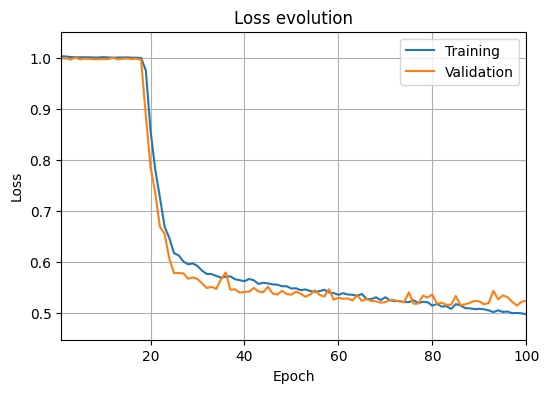

In [9]:
history = checkpoint["history"]

train_loss = history["train_loss"]
val_loss = history["val_loss"]

import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 1, figsize=(6, 4))

last_epoch = len(train_loss)
plt.plot(np.arange(1, last_epoch+1), train_loss, label="Training")
plt.plot(np.arange(1, last_epoch+1), val_loss, label="Validation")
ax.set_xlim(1, last_epoch)
ax.set_ylim(min(train_loss)-0.05, max(val_loss)+0.05)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss evolution")
ax.legend()
ax.grid()


### Load the best checkpoint

In [10]:
import torch
from src.models.network import SimpleCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

config = checkpoint["model_config"]

model = SimpleCNN(
    n_detectors=config["n_detectors"],
    n_outputs=config["n_outputs"],
    embedding_dim=config["embedding_dim"],
    dropout_conv=config["dropout_conv"],
    dropout_dense=config["dropout_dense"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

y_mean_loaded = checkpoint["y_mean"].cpu().numpy()
y_std_loaded = checkpoint["y_std"].cpu().numpy()

print("Loaded epoch:", checkpoint["epoch"])
print("Loaded val loss:", checkpoint["best_val_loss"])

Loaded epoch: 98
Loaded val loss: 0.513808821439743


In [ ]:
import torch.nn as nn

xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

model = SimpleCNN(
    n_detectors=3,
    n_outputs=3,
    embedding_dim=64,
    dropout_conv=0.05,
    dropout_dense=0.1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = nn.MSELoss()

model.train()
optimizer.zero_grad()

pred = model(xb)
loss = loss_fn(pred, yb)
loss.backward()

print("loss:", loss.item())
print("pred mean:", pred.detach().mean(dim=0))
print("pred std:", pred.detach().std(dim=0))
print("target mean:", yb.mean(dim=0))
print("target std:", yb.std(dim=0))

for name, p in model.named_parameters():
    if p.grad is not None:
        print(name, p.grad.abs().mean().item())
        break

loss: 1.1248223781585693
pred mean: tensor([0.0873, 0.0488, 0.0799], device='cuda:0')
pred std: tensor([0.0250, 0.0235, 0.0139], device='cuda:0')
target mean: tensor([0.3734, 0.3064, 0.1657], device='cuda:0')
target std: tensor([1.1353, 1.1259, 0.8781], device='cuda:0')
block1.conv.weight 0.0002444889396429062


In [11]:
from src.models.evaluate import compute_error_metrics, predict_on_loader

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

pred_val_std, y_val_std_loader = predict_on_loader(
    model=model,
    loader=val_loader,
    device=device,
)

pred_val_phys = pred_val_std * y_std_safe + y_mean
y_val_phys_loader = y_val_std_loader * y_std_safe + y_mean

metrics_val_std = compute_error_metrics(
    pred=pred_val_std,
    y_true=y_val_std_loader,
    label_names=label_names,
)

metrics_val_phys = compute_error_metrics(
    pred=pred_val_phys,
    y_true=y_val_phys_loader,
    label_names=label_names,
)



metrics_val_std, metrics_val_phys

({'global_mse': 0.5138086676597595,
  'global_mae': 0.5677380561828613,
  'per_label': {'chirp_mass': {'mse': 0.39991453289985657,
    'mae': 0.48783764243125916},
   'total_mass': {'mse': 0.3590420186519623, 'mae': 0.4919798970222473},
   'chi_eff': {'mse': 0.7824693918228149, 'mae': 0.7233967185020447}}},
 {'global_mse': 174.37298583984375,
  'global_mae': 8.344624519348145,
  'per_label': {'chirp_mass': {'mse': 106.50103759765625,
    'mae': 7.961017608642578},
   'total_mass': {'mse': 416.46759033203125, 'mae': 16.75580596923828},
   'chi_eff': {'mse': 0.1503022313117981, 'mae': 0.31704840064048767}}})

In [11]:
pred_test_std, y_test_std_loader = predict_on_loader(
    model=model,
    loader=test_loader,
    device=device,
)

pred_test_phys = pred_test_std * y_std_safe + y_mean
y_test_phys_loader = y_test_std_loader * y_std_safe + y_mean

metrics_test_std = compute_error_metrics(
    pred=pred_test_std,
    y_true=y_test_std_loader,
    label_names=label_names,
)

metrics_test_phys = compute_error_metrics(
    pred=pred_test_phys,
    y_true=y_test_phys_loader,
    label_names=label_names,
)

metrics_test_std, metrics_test_phys

({'global_mse': 0.45080164074897766,
  'global_mae': 0.516883134841919,
  'per_label': {'chirp_mass': {'mse': 0.43452852964401245,
    'mae': 0.4802187979221344},
   'total_mass': {'mse': 0.330777645111084, 'mae': 0.44916749000549316},
   'chi_eff': {'mse': 0.5870987772941589, 'mae': 0.6212630867958069}}},
 {'global_mse': 166.50469970703125,
  'global_mae': 7.802222728729248,
  'per_label': {'chirp_mass': {'mse': 115.71902465820312,
    'mae': 7.836686611175537},
   'total_mass': {'mse': 383.68231201171875, 'mae': 15.29769515991211},
   'chi_eff': {'mse': 0.11277398467063904, 'mae': 0.2722852826118469}}})

Save the best checkpoint

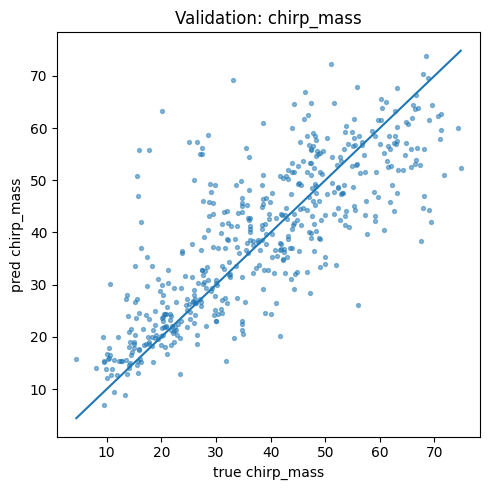

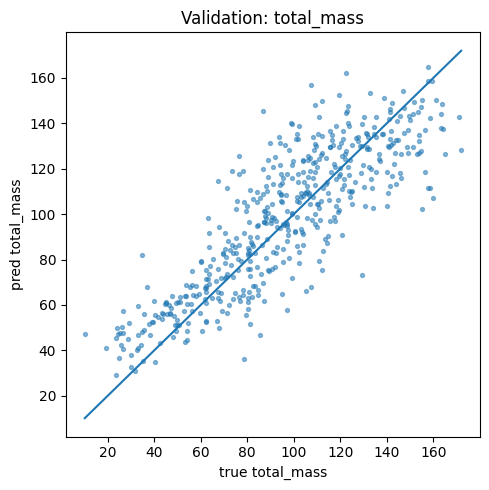

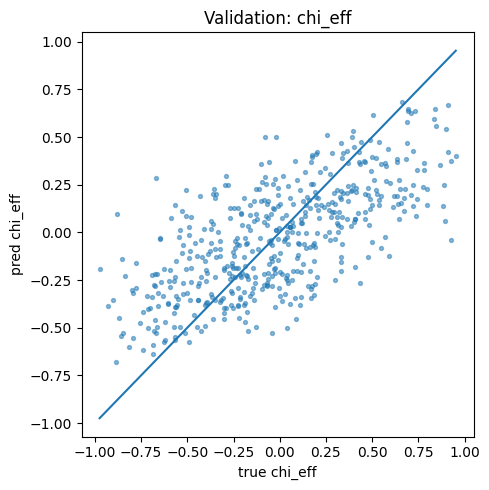

In [12]:
import matplotlib.pyplot as plt

for j, name in enumerate(label_names):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_val_phys_loader[:, j], pred_val_phys[:, j], s=8, alpha=0.5)
    
    lo = min(y_val_phys_loader[:, j].min(), pred_val_phys[:, j].min())
    hi = max(y_val_phys_loader[:, j].max(), pred_val_phys[:, j].max())
    plt.plot([lo, hi], [lo, hi])
    
    plt.xlabel(f"true {name}")
    plt.ylabel(f"pred {name}")
    plt.title(f"Validation: {name}")
    plt.tight_layout()
    plt.show()

## Load model from best checkpoint

In [ ]:
import torch
from src.models.network import SimpleCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_file_name = "SimpleCNN_GN_v1_N5000_seed13_bestval0.5850.pt"

checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

config = checkpoint["model_config"]

model = SimpleCNN(
    n_detectors=config["n_detectors"],
    n_outputs=config["n_outputs"],
    embedding_dim=config["embedding_dim"],
    dropout_conv=config["dropout_conv"],
    dropout_dense=config["dropout_dense"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

y_mean_loaded = checkpoint["y_mean"].cpu().numpy()
y_std_loaded = checkpoint["y_std"].cpu().numpy()

print("Loaded epoch:", checkpoint["epoch"])
print("Loaded val loss:", checkpoint["best_val_loss"])

## Save metrics in json

Save metrics in a json file

In [ ]:
import json

seed = 13
best_checkpoint = checkpoint

metrics = {
    "checkpoint_file": checkpoint_file_name,
    "seed": seed,
    "best_epoch": int(best_checkpoint["epoch"]),
    "train_loss_at_best": float(best_checkpoint["train_loss"]),
    "val_loss_at_best": float(best_checkpoint["best_val_loss"]),
    "model_config": best_checkpoint["model_config"],
    "training_config": best_checkpoint["training_config"],
    "elapsed_seconds": float(best_checkpoint["elapsed_seconds"]),
    "history": best_checkpoint["history"],
}

metrics_path = RESULTS_DIR / checkpoint_file_name.replace(".pt", "_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics to:", metrics_path)

Check and save values for val(test)

In [ ]:
from src.models.evaluate import predict_on_loader, compute_error_metrics

label_names = ["chirp_mass", "total_mass", "chi_eff"]


pred_val, y_val = predict_on_loader(model, val_loader, device)
error_metrics_val = compute_error_metrics(pred_val, y_val, label_names)


for i, name in enumerate(label_names):
    print(f"{name}")
    print(f"  val  MSE={error_metrics_val['per_label'][name]['mse']:.4f}, MAE={error_metrics_val['per_label'][name]['mae']:.4f}")
    

Add it to the json file

In [ ]:
metrics["val_mse_per_label"] = {
    name: float(error_metrics_val["per_label"][name]["mse"]) for name in label_names
}

metrics["val_mae_per_label"] = {
    name: float(error_metrics_val["per_label"][name]["mae"]) for name in label_names
}

metrics["val_loss_global_mse"] = error_metrics_val["global_mse"]
metrics["val_loss_global_mae"] = error_metrics_val["global_mae"]
 

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

Structure:
checkpoint .pt  -> weights + scaler + config
metrics .json     -> resultados legibles

## Repeat for several seeds

## Extraer predicciones y embeddings (After training)

Get the predictions, embeddings and labels for the calibration and test sets.

In [ ]:
from src.models.evaluate import extract_predictions_and_embeddings

pred_cal, emb_cal, y_cal = extract_predictions_and_embeddings(
    model,
    cal_loader,
    device,
)

pred_test, emb_test, y_test = extract_predictions_and_embeddings(
    model,
    test_loader,
    device,
)

And the we save all the results (predictions, embeddings, labels) to use later in Mondrian.

In [ ]:
embeddings_file = checkpoint_file_name.replace(".pt", "_predictions_embeddings.npz")

np.savez_compressed(
    RESULTS_DIR / embeddings_file,
    pred_cal=pred_cal,
    emb_cal=emb_cal,
    y_cal=y_cal,
    pred_test=pred_test,
    emb_test=emb_test,
    y_test=y_test,
    y_mean=y_mean,
    y_std=y_std,
    checkpoint_file=checkpoint_file_name,
)

print("Embeddings saved to:", RESULTS_DIR / embeddings_file)

## Plots

Plot the predictions vs the true values of the validation set

In [ ]:
from src.models.evaluate import predict_on_loader

pred_val_std, y_val_std = predict_on_loader(
    model,
    val_loader,
    device,
)


y_mean = checkpoint["y_mean"].cpu().numpy()
y_std = checkpoint["y_std"].cpu().numpy()

pred_val = pred_val_std * y_std + y_mean
y_val_true = y_val_std * y_std + y_mean

In [ ]:
#Plot pred vs true for the 3 labels (chirp_mass, total_mass, chi_eff)
import matplotlib.pyplot as plt
import numpy as np

label_names = ["chirp_mass", "total_mass", "chi_eff"]

for j, name in enumerate(label_names):
    plt.figure(figsize=(5, 5))

    plt.scatter(
        y_val_true[:, j],
        pred_val[:, j],
        s=8,
        alpha=0.5,
    )

    min_val = min(y_val_true[:, j].min(), pred_val[:, j].min())
    max_val = max(y_val_true[:, j].max(), pred_val[:, j].max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f"Validation: true vs predicted - {name}")
    plt.grid(True)
    plt.show()




Also plot the residuals

In [ ]:
for j, name in enumerate(label_names):
    residual = y_val_true[:, j] - pred_val[:, j]

    plt.figure(figsize=(6, 4))

    plt.scatter(
        y_val_true[:, j],
        residual,
        s=8,
        alpha=0.5,
    )

    plt.axhline(0.0, linestyle="--", linewidth=1)

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Residual true - pred")
    plt.title(f"Validation residuals - {name}")
    plt.grid(True)
    plt.show()

### Testing the GPU

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("Total VRAM [GB]:", props.total_memory / 1024**3)

In [ ]:

print("Allocated [GB]:", torch.cuda.memory_allocated() / 1024**3)
print("Reserved [GB]:", torch.cuda.memory_reserved() / 1024**3)
print("Peak allocated [GB]:", torch.cuda.max_memory_allocated() / 1024**3)
print("Peak reserved [GB]:", torch.cuda.max_memory_reserved() / 1024**3)

In [ ]:
def test_batch_size(model, batch_size, n_detectors=3, signal_length=16384, device="cuda"):
    try:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        model.train()

        X = torch.randn(batch_size, n_detectors, signal_length, device=device)
        y = torch.randn(batch_size, 3, device=device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        loss_fn = torch.nn.MSELoss()

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        peak = torch.cuda.max_memory_allocated() / 1024**3
        print(f"batch_size={batch_size} OK | peak VRAM = {peak:.2f} GB")

        del X, y, pred, loss
        torch.cuda.empty_cache()

        return True

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"batch_size={batch_size} OOM")
            torch.cuda.empty_cache()
            return False
        else:
            raise e

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for bs in [32, 64, 96, 128, 192]:
    if device == "cuda":
        ok = test_batch_size(model, bs, device=device)
        if not ok:
            break